In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

In [3]:
data = pd.read_csv('Titanic-Dataset.csv')

In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket', 'Pclass'], inplace = True)

categorical_features = ['Sex', 'Embarked', 'Survived']
numeric_features = [x for x in list(data.columns) if x not in categorical_features]
#numeric_features = ['latitude', 'longitude', 'price', 'minimum_nights']


data[numeric_features] = data[numeric_features].fillna(data[numeric_features].median())

data[categorical_features] = data[categorical_features].fillna(data[categorical_features].mode().iloc[0])
data = pd.get_dummies(data, columns = categorical_features, dtype=int)

sc = StandardScaler()
data[numeric_features] = sc.fit_transform(data[numeric_features])

y = data[['Survived_0', 'Survived_1']]
X = data.drop(columns = ['Survived_0', 'Survived_1'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

dataset_train = pd.concat([X_train, y_train], axis = 1)
#dataset_test = pd.concat([X_test, y_test], axis = 1)

In [6]:
dataset_train.head()

,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Survived_0,Survived_1
599,1.509209,0.497830,0,1,1,0,0,0,1
830,-1.103685,-0.357391,1,0,1,0,0,0,1
306,-0.104637,1.584179,1,0,1,0,0,0,1
231,-0.027788,-0.491874,0,1,0,0,1,1,0
845,0.971260,-0.496405,0,1,0,0,1,1,0


In [7]:
class LanguageModelDataLoader(DataLoader):
    def __init__(self, dataset, batch_size, columns, shuffle=True):
        
        self.data = dataset
        self.batch_size = batch_size
        self.cuda = False
        self.columns = columns

    def __iter__(self):
        # concatenate your articles and build into batches
        shuffled = np.random.permutation(self.data)
        #print(shuffled.shape, self.columns)
        shuffled = pd.DataFrame(shuffled, columns = self.columns)
        count = len(shuffled)
        num_batches = (count - 1)//self.batch_size
        number = num_batches * self.batch_size
        #print(shuffled, type(shuffled))
        y = np.array(shuffled[['Survived_0', 'Survived_1']])
        x = np.array(shuffled.drop(columns = ['Survived_0', 'Survived_1']))
        
        x = torch.from_numpy(x)
        y = torch.from_numpy(y)
        if self.cuda:
            x = x.cuda()
            y = y.cuda()
        
        start = 0
        while start < num_batches:
            if (np.random.uniform() < 0.95):
                L = round(np.random.normal(70,5))
            else:
                L = round(np.random.normal(35,5))
            x_out = x[start:start + L]
            y_out = y[start:start + L]
            start = start + L
            yield x_out,y_out 

In [8]:
class LanguageModel(nn.Module):
    def __init__(self):
        super(LanguageModel, self).__init__()
        # self.vocab_size = charcount
        # self.embedding = nn.Embedding(self.vocab_size,400)
        self.linear = nn.ModuleList()
        self.linear.append(nn.Linear(7,64))
        self.linear.append(nn.Linear(64,32))
        self.linear.append(nn.Linear(32,2))
        
    def forward(self, out):
        batch_size = out.size(1)
        #embed = self.embedding(seq_batch)
        #print(out.dtype)
        for layers in self.linear:
            out = layers(out)
        #print(out.size())
        return out

In [9]:
class LanguageModelTrainer:
    def __init__(self, model, loader, max_epochs=1, run_id='exp'):
        # feel free to add any other parameters here
        self.model = model
        self.loader = loader
        self.predictions = []
        self.epochs = 0
        self.max_epochs = max_epochs
        self.run_id = run_id
        self.sigmoid = nn.Sigmoid()
        self.train_losses = []
        
        # TODO: Define your optimizer and criterion here
        self.optimizer = torch.optim.Adam(model.parameters(),lr=0.001, weight_decay=1e-6)
        self.criterion = nn.BCELoss().to(DEVICE)

    def train(self):
        self.model.train() # set to training mode
        epoch_loss = 0
        num_batches = 0
        for batch_num, (inputs, targets) in enumerate(self.loader):
            epoch_loss += self.train_batch(inputs, targets)
        epoch_loss = epoch_loss / (batch_num + 1)
        self.epochs += 1
        if self.epochs % 5 == 0:
            print('[TRAIN]  Epoch [%d/%d]   Loss: %.4f'
                      % (self.epochs, self.max_epochs, epoch_loss.item()))
        self.train_losses.append(epoch_loss.item())

    def train_batch(self, inputs, targets):
        inputs = inputs.to(DEVICE).long()
        targets = targets.to(torch.float32)
        outputs = self.model(inputs.to(torch.float32))
        outputs = self.sigmoid(outputs)
        #print((outputs[:,0]), (outputs[:,1]), targets)
        loss = self.criterion(outputs, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss

In [10]:
class TestLanguageModel:
    def prediction(inp, model):
        inp = torch.from_numpy(inp)
        inp = inp.to(torch.float32)
        h = model(inp)
        #print(h.shape, h)
        h = h
        return h.cpu().data.numpy()

In [11]:
#hyperparameters here

NUM_EPOCHS = 450
BATCH_SIZE = 64

In [12]:
model = LanguageModel()
loader = LanguageModelDataLoader(dataset=dataset_train, batch_size=BATCH_SIZE, columns = dataset_train.columns, shuffle=True)
trainer = LanguageModelTrainer(model=model, loader=loader, max_epochs=NUM_EPOCHS)

In [13]:
model = model.to(DEVICE)

In [23]:
best_nll = 1e30  # set to super large value at first
for epoch in range(NUM_EPOCHS):
    last_layer = nn.Sigmoid()
    trainer.train()
    predictions = last_layer(torch.from_numpy(TestLanguageModel.prediction(np.array(X_test), model)))
    # nll = trainer.test()
    # if nll < best_nll:
    #     best_nll = nll
    #     print("Saving model, predictions and generated output for epoch " + 
    #           str(epoch)+" with NLL: " + str(best_nll))
    #     trainer.save()

[TRAIN]  Epoch [455/450]   Loss: 0.4400
[TRAIN]  Epoch [460/450]   Loss: 0.5182
[TRAIN]  Epoch [465/450]   Loss: 0.5231
[TRAIN]  Epoch [470/450]   Loss: 0.4492
[TRAIN]  Epoch [475/450]   Loss: 0.5645
[TRAIN]  Epoch [480/450]   Loss: 0.5457
[TRAIN]  Epoch [485/450]   Loss: 0.4809
[TRAIN]  Epoch [490/450]   Loss: 0.5980
[TRAIN]  Epoch [495/450]   Loss: 0.5693
[TRAIN]  Epoch [500/450]   Loss: 0.4872
[TRAIN]  Epoch [505/450]   Loss: 0.3939
[TRAIN]  Epoch [510/450]   Loss: 0.4195
[TRAIN]  Epoch [515/450]   Loss: 0.5056
[TRAIN]  Epoch [520/450]   Loss: 0.6002
[TRAIN]  Epoch [525/450]   Loss: 0.5473
[TRAIN]  Epoch [530/450]   Loss: 0.5207
[TRAIN]  Epoch [535/450]   Loss: 0.4574
[TRAIN]  Epoch [540/450]   Loss: 0.5469
[TRAIN]  Epoch [545/450]   Loss: 0.5173
[TRAIN]  Epoch [550/450]   Loss: 0.5205
[TRAIN]  Epoch [555/450]   Loss: 0.3775
[TRAIN]  Epoch [560/450]   Loss: 0.5711
[TRAIN]  Epoch [565/450]   Loss: 0.5583
[TRAIN]  Epoch [570/450]   Loss: 0.4294
[TRAIN]  Epoch [575/450]   Loss: 0.4976


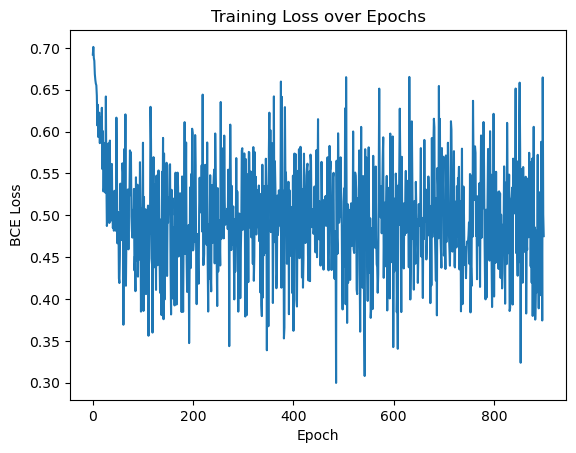

In [24]:
plt.plot(trainer.train_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.show()

In [25]:
out = pd.DataFrame(predictions, columns = ['Survived_0', 'Survived_1'])

In [26]:
def accuracy(outputs, labels):
    
    _, preds = torch.max(outputs, dim=1)
    labels['Survived'] = labels.apply(lambda x: 0 if x['Survived_0'] == 1 else 1, axis=1)
    labels = torch.tensor(labels['Survived'].values)
       
    return preds, torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [27]:
preds, score = accuracy(predictions, y_test)

In [28]:
out = pd.DataFrame({'Predictions': preds, 'Actual_output': y_test['Survived'].values})

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test['Survived'].values, preds.numpy()))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        78
           1       0.76      0.70      0.73        56

    accuracy                           0.78       134
   macro avg       0.78      0.77      0.77       134
weighted avg       0.78      0.78      0.78       134



In [30]:
score

tensor(0.7836)